In [28]:
import pandas as pd


In [4]:
df = pd.read_csv('../data/online_retail_II.csv')
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.describe()


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [54]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Roughly 20-25% of the transactional rows have a missing CustomerID. These typically represent guest checkouts or unregistered buyers. We can handle them differently:
- assign a unique 'guest id'
- drop from the main dataset and tream them separately.

This is not a data that not recorded, this is a special case.
We will decide later how to deal with this.

In [60]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

<Axes: title={'center': 'Top 5 Countries by Number of Transactions'}, ylabel='count'>

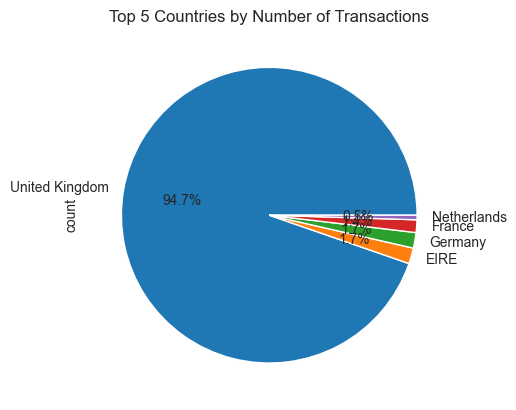

In [64]:
# plot pie chart of the top 5 countries by number of transactions
top_countries = df['Country'].value_counts().head(5)
top_countries.plot(kind='pie', autopct='%1.1f%%', title='Top 5 Countries by Number of Transactions')

<Axes: title={'center': 'Top 10 Countries Excluding UK by Number of Transactions'}, ylabel='count'>

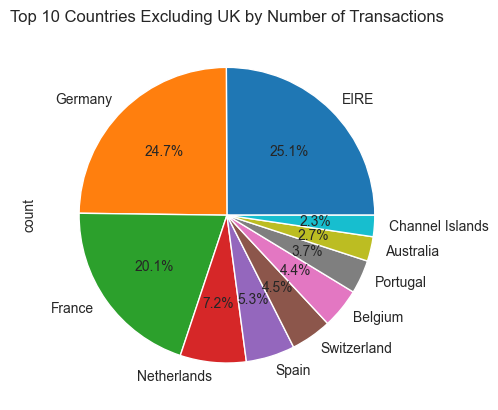

In [67]:
# plot pie char of top 10 countries excluding UK
countries_excluding_uk = df[df['Country'] != 'United Kingdom']['Country'].value_counts().head(10)

countries_excluding_uk.plot(kind='pie', autopct='%1.1f%%', title='Top 10 Countries Excluding UK by Number of Transactions')


<Axes: title={'center': 'Distribution of Day of Week of Transactions in UK'}, ylabel='count'>

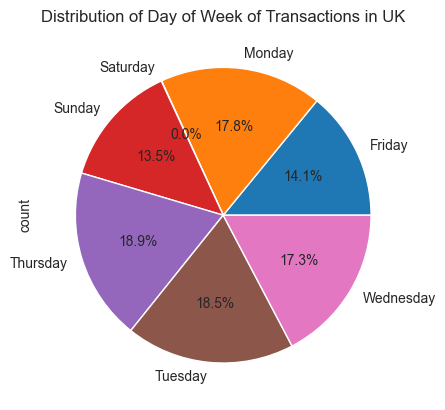

In [79]:
# plot distribution of day of week of transactions using pandas built-in plot function in UK only
uk_transactions = df[df['Country'] == 'United Kingdom'].copy()

# Infer the day of week from the InvoiceDate column
uk_transactions['InvoiceDate'] = pd.to_datetime(uk_transactions['InvoiceDate'])
uk_transactions['DayOfWeek'] = uk_transactions['InvoiceDate'].dt.day_name()
uk_transactions['DayOfWeek'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', title='Distribution of Day of Week of Transactions in UK')


<Axes: title={'center': 'Distribution of Month of Transactions in UK'}, ylabel='count'>

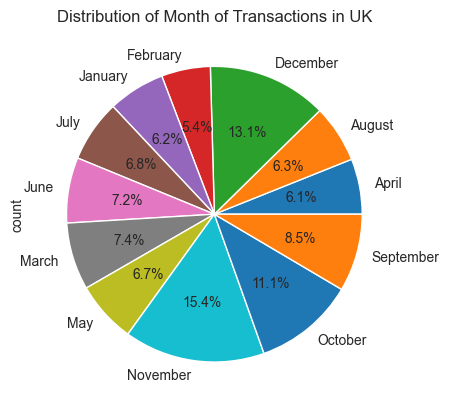

In [78]:
# plot distribution of month of transactions using pandas built-in plot function in UK only
uk_transactions['Month'] = uk_transactions['InvoiceDate'].dt.month_name()
uk_transactions['Month'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', title='Distribution of Month of Transactions in UK')


<Axes: title={'center': 'Distribution of Hour of Transactions in UK'}, xlabel='Hour'>

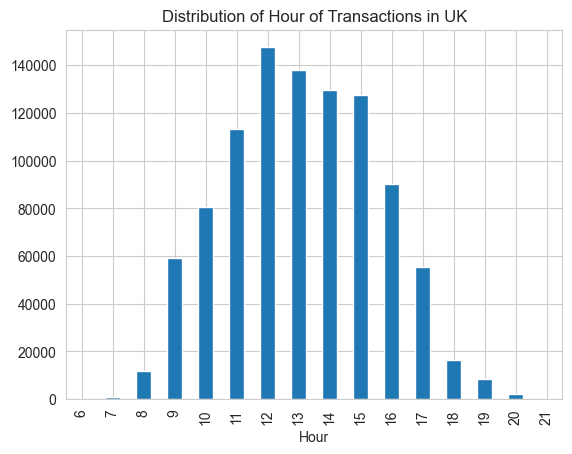

In [ ]:
# plot distribution of hoour of transactions using pandas built-in plot function in UK only. Hours are in 24-hour format, so the x-axis will be from 0 to 23
uk_transactions['Hour'] = uk_transactions['InvoiceDate'].dt.hour
uk_transactions['Hour'].value_counts().sort_index().plot(kind='bar', title='Distribution of Hour of Transactions in UK')

In [57]:
# Negative quantities in the Online Retail II dataset primarily represent order cancellations and returns, which are often indicated 
# by  an invoice number starting with the letter 'C'
# https://www.kaggle.com/code/mustafagerme/arl-using-the-dataset-online-retail-ii
#
# This is my prospect for data mining: who are the customers who return products, and what are the products that are returned most often?

df_negative = df[df.Quantity < 0]
df_negative.describe()

,Quantity,Price,Customer ID
count,22950.000000,22950.000000,18744.000000
mean,-46.365054,38.098715,15014.418694
std,788.250496,549.831443,1698.413277
min,-80995.000000,0.000000,12346.000000
25%,-11.000000,0.850000,13552.000000
50%,-2.000000,2.250000,14911.000000
75%,-1.000000,4.950000,16401.000000
max,-1.000000,38970.000000,18287.000000


In [56]:
df_positive = df[df.Quantity > 0]
df_positive.describe()

,Quantity,Price,Customer ID
count,1.044421e+06,1.044421e+06,805620.000000
mean,1.117612e+01,3.914376e+00,15331.856250
std,1.294560e+02,9.451415e+01,1696.768395
min,1.000000e+00,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13982.000000
50%,3.000000e+00,2.100000e+00,15271.000000
75%,1.000000e+01,4.130000e+00,16805.000000
max,8.099500e+04,2.511109e+04,18287.000000


In [58]:
# Negative values in the Price column of the Online Retail II dataset represent order cancellations, product returns, or administrative bank fees/adjustments.
# https://www.kaggle.com/code/mustafagerme/arl-using-the-dataset-online-retail-ii
#
# This is my prospect for data mining: who are the customers who cancel orders, and what are the products that are cancelled most often?
df_cancellations = df[df.Price < 0]
df_cancellations.describe()


,Quantity,Price,Customer ID
count,5.0,5.000000,0.0
mean,1.0,-31735.228000,NaN
std,0.0,19592.678298,NaN
min,1.0,-53594.360000,NaN
25%,1.0,-44031.790000,NaN
50%,1.0,-38925.870000,NaN
75%,1.0,-11062.060000,NaN
max,1.0,-11062.060000,NaN


In [59]:
# not-cancellation transactions
non_cancel_df = df[df.Price >= 0]
non_cancel_df.describe()

,Quantity,Price,Customer ID
count,1.067366e+06,1.067366e+06,824364.000000
mean,9.938940e+00,4.798071e+00,15324.638504
std,1.727062e+02,9.543393e+01,1697.464450
min,-8.099500e+04,0.000000e+00,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


Text(0, 0.5, 'Number of StockCodes (log scale)')

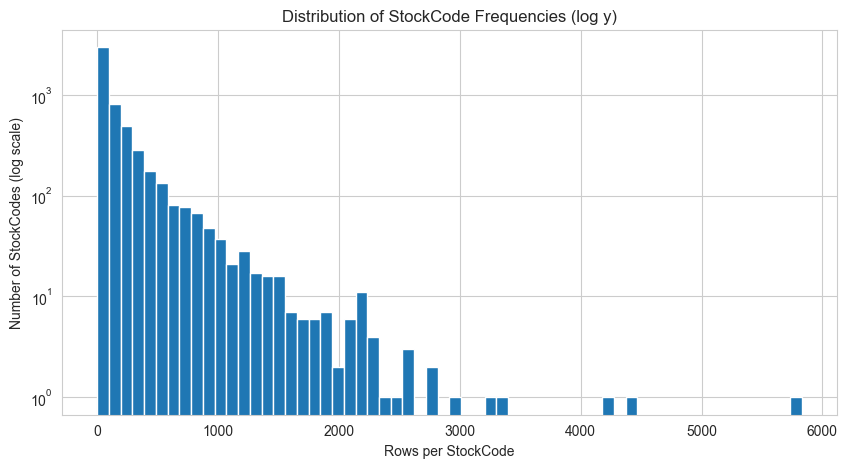

In [ ]:
stockcode_counts = df['StockCode'].value_counts(dropna=False)

ax = stockcode_counts.plot(
    kind='hist',
    bins=60,
    logy=True,
    figsize=(10, 5),
    title='Distribution of StockCode Frequencies (log y)'
)   

ax.set_xlabel('Rows per StockCode')
ax.set_ylabel('Number of StockCodes (log scale)')

<Axes: title={'center': 'Distribution of Negative Quantity'}, ylabel='Frequency'>

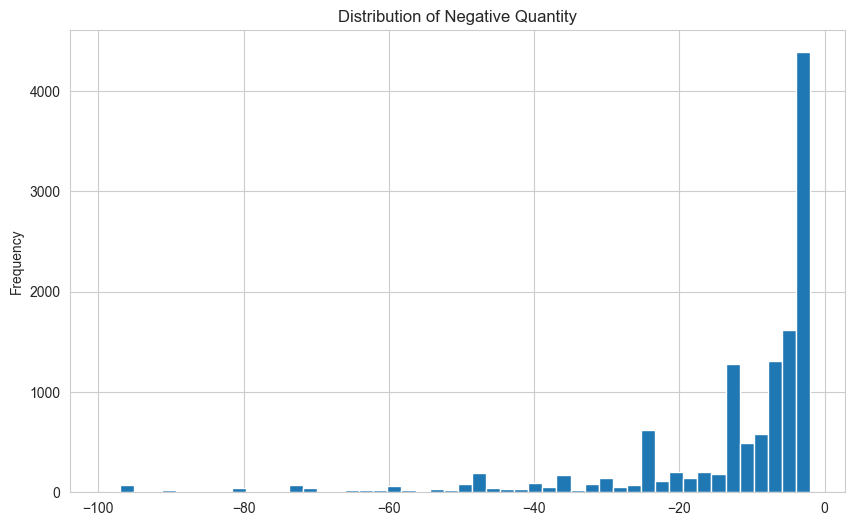

In [ ]:
# plot distribution of 'Quantity' column in negative values using pandas built-in plot function
# need to drop the outliers in order to see the distribution of the majority of the data
# drop the top and bottom 5% of the data to remove outliers

q_low = df_negative["Quantity"].quantile(0.05)
q_high = df_negative["Quantity"].quantile(0.95)
df_negative_filtered = df_negative[(df_negative["Quantity"] > q_low) & (df_negative["Quantity"] < q_high)]

df_negative_filtered.Quantity.plot(kind='hist', bins=50, figsize=(10, 6), title='Distribution of Negative Quantity')

<Axes: title={'center': 'Distribution of Price in Non-Cancellation Transactions'}, ylabel='Frequency'>

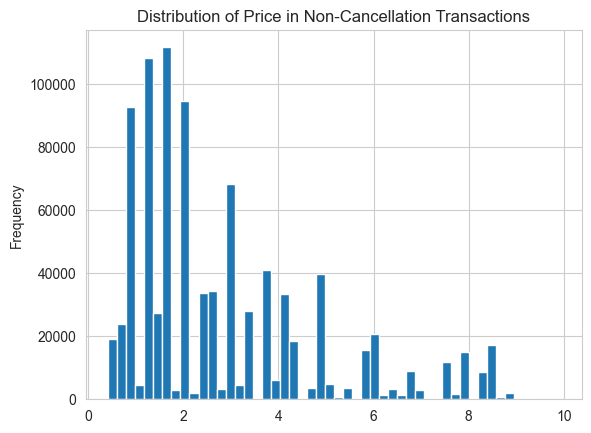

In [62]:
# plot distribution of 'Price' column in non-cancellation values using pandas built-in plot function
# need to drop the outliers in order to see the distribution of the majority of the data
q_low = non_cancel_df["Price"].quantile(0.05)
q_high = non_cancel_df["Price"].quantile(0.95)
non_cancel_df = non_cancel_df[(non_cancel_df["Price"] > q_low) & (non_cancel_df["Price"] < q_high)]
non_cancel_df['Price'].plot(kind='hist', bins=50, title='Distribution of Price in Non-Cancellation Transactions')
